In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!ls /content/drive


MyDrive


In [3]:
import os
os.makedirs('/content/drive/MyDrive/VisionExtract', exist_ok=True)


In [4]:
!pip install pycocotools albumentations


In [5]:
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip



--2026-02-19 10:03:30--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.136.233, 16.15.199.129, 16.182.98.41, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.136.233|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  69.3MB/s    in 4m 28s  

2026-02-19 10:07:58 (68.8 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2026-02-19 10:07:58--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.9.225, 3.5.27.123, 54.231.232.121, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.9.225|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_tra

In [6]:
import torch
torch.cuda.is_available()


True

In [7]:
!unzip train2017.zip
!unzip annotations_trainval2017.zip


Streaming output truncated to the last 5000 lines.
 extracting: train2017/000000563584.jpg  
 extracting: train2017/000000276069.jpg  
 extracting: train2017/000000401194.jpg  
 extracting: train2017/000000502089.jpg  
 extracting: train2017/000000192183.jpg  
 extracting: train2017/000000425127.jpg  
 extracting: train2017/000000126766.jpg  
 extracting: train2017/000000324161.jpg  
 extracting: train2017/000000452746.jpg  
 extracting: train2017/000000423782.jpg  
 extracting: train2017/000000546343.jpg  
 extracting: train2017/000000249290.jpg  
 extracting: train2017/000000025529.jpg  
 extracting: train2017/000000316928.jpg  
 extracting: train2017/000000337866.jpg  
 extracting: train2017/000000547768.jpg  
 extracting: train2017/000000423162.jpg  
 extracting: train2017/000000224149.jpg  
 extracting: train2017/000000117841.jpg  
 extracting: train2017/000000251660.jpg  
 extracting: train2017/000000110997.jpg  
 extracting: train2017/000000424728.jpg  
 extracting: train2017/00

In [8]:
from pycocotools.coco import COCO
import numpy as np
import cv2

In [9]:
coco = COCO("annotations/instances_train2017.json")

loading annotations into memory...
Done (t=13.62s)
creating index...
index created!


In [10]:
cat_ids = coco.getCatIds(catNms=['person'])

In [12]:
def get_mask(img_id):
    img_info = coco.loadImgs(img_id)[0]
    height, width = img_info['height'], img_info['width']

    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((height, width))
    for ann in anns:
        mask += coco.annToMask(ann)

    mask = (mask > 0).astype(np.uint8)
    return mask


In [13]:
from torch.utils.data import Dataset
import torch
import os

class CocoSegDataset(Dataset):
    def __init__(self, img_ids, transform=None):
        self.img_ids = img_ids
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join("train2017", img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = get_mask(img_id)

        image = cv2.resize(image, (256,256))
        mask = cv2.resize(mask, (256,256))

        image = torch.tensor(image).permute(2,0,1).float()/255.0
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask


In [14]:
img_ids = coco.getImgIds(catIds=cat_ids)
img_ids = img_ids[:3000]   # limit to 3000 images


In [15]:
train_ids = img_ids[:2400]
val_ids = img_ids[2400:]


In [16]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.8 MB/s eta 0:00:00


In [17]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model = model.cuda()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [18]:
import torch.nn as nn

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [19]:
for epoch in range(5):
    model.train()
    for images, masks in train_loader:
        images, masks = images.cuda(), masks.cuda()

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())


NameError: name 'train_loader' is not defined

In [20]:
from torch.utils.data import DataLoader

train_dataset = CocoSegDataset(train_ids)
val_dataset = CocoSegDataset(val_ids)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [21]:
for epoch in range(5):
    model.train()
    for images, masks in train_loader:
        images, masks = images.cuda(), masks.cuda()

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.19111624360084534
Epoch: 1 Loss: 0.15619206428527832
Epoch: 2 Loss: 0.2701222896575928
Epoch: 3 Loss: 0.1318359375
Epoch: 4 Loss: 0.08285216987133026


In [22]:
def iou_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return intersection / union

In [23]:
model.eval()
image, mask = val_dataset[0]
image = image.unsqueeze(0).cuda()

with torch.no_grad():
    pred = model(image)

pred = torch.sigmoid(pred)
pred = (pred > 0.5).float()

output = image * pred

In [24]:
def iou_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()


In [25]:
model.eval()

image, mask = val_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(image)

pred = torch.sigmoid(pred)
pred = (pred > 0.5).float()

# Apply mask
output = image * pred

# Convert for display
output = output.squeeze(0).cpu().permute(1,2,0).numpy()

NameError: name 'device' is not defined

In [26]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [27]:
model = model.to(device)

In [28]:
model.eval()

image, mask = val_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(image)

pred = torch.sigmoid(pred)
pred = (pred > 0.5).float()

output = image * pred
output = output.squeeze(0).cpu().permute(1,2,0).numpy()

In [29]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, "/content/drive/MyDrive/VisionExtract/model.pth")

In [30]:
model.eval()
total_iou = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        total_iou += iou_score(outputs, masks)

print("Validation IoU:", total_iou / len(val_loader))

Validation IoU: 0.5133656130172313


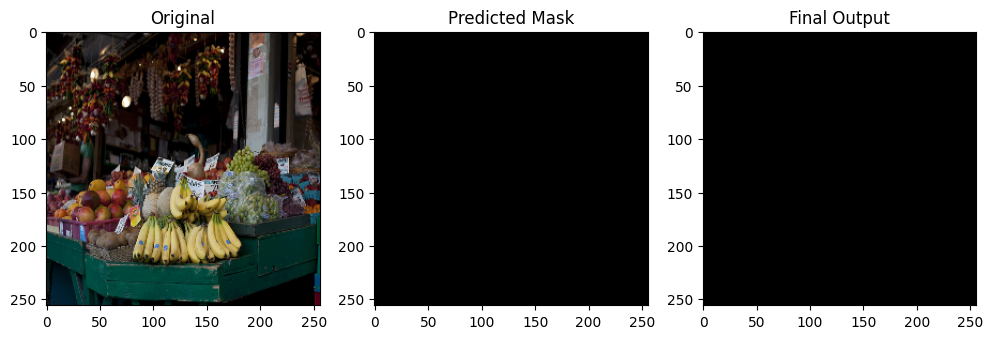

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image.squeeze(0).cpu().permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(pred.squeeze(0).cpu().squeeze(0), cmap='gray')

plt.subplot(1,3,3)
plt.title("Final Output")
plt.imshow(output)

plt.show()

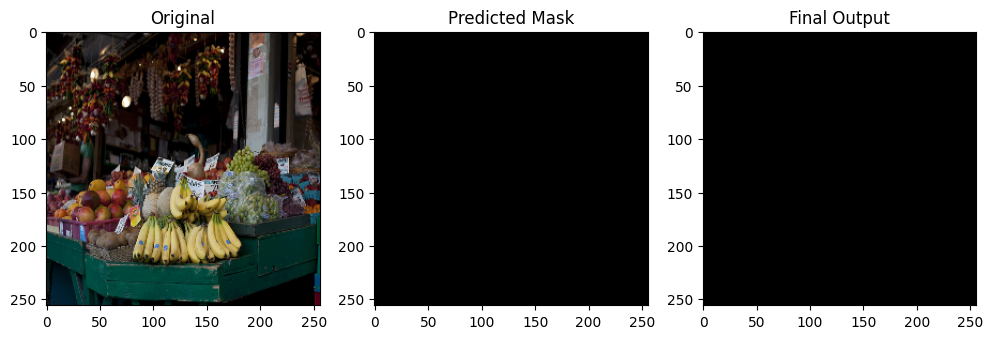

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image.squeeze(0).cpu().permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(pred.squeeze(0).cpu().squeeze(0), cmap='gray')

plt.subplot(1,3,3)
plt.title("Final Output")
plt.imshow(output)

plt.show()

In [34]:
torch.save(model.state_dict(),
"/content/drive/MyDrive/VisionExtract/final_model.pth")

In [35]:
cats = coco.loadCats(coco.getCatIds())
for cat in cats:
    print(cat['id'], cat['name'])

1 person
2 bicycle
3 car
4 motorcycle
5 airplane
6 bus
7 train
8 truck
9 boat
10 traffic light
11 fire hydrant
13 stop sign
14 parking meter
15 bench
16 bird
17 cat
18 dog
19 horse
20 sheep
21 cow
22 elephant
23 bear
24 zebra
25 giraffe
27 backpack
28 umbrella
31 handbag
32 tie
33 suitcase
34 frisbee
35 skis
36 snowboard
37 sports ball
38 kite
39 baseball bat
40 baseball glove
41 skateboard
42 surfboard
43 tennis racket
44 bottle
46 wine glass
47 cup
48 fork
49 knife
50 spoon
51 bowl
52 banana
53 apple
54 sandwich
55 orange
56 broccoli
57 carrot
58 hot dog
59 pizza
60 donut
61 cake
62 chair
63 couch
64 potted plant
65 bed
67 dining table
70 toilet
72 tv
73 laptop
74 mouse
75 remote
76 keyboard
77 cell phone
78 microwave
79 oven
80 toaster
81 sink
82 refrigerator
84 book
85 clock
86 vase
87 scissors
88 teddy bear
89 hair drier
90 toothbrush


In [36]:
target_classes = [
    'person',
    'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
    'banana','apple','sandwich','orange','broccoli','carrot',
    'hot dog','pizza','donut','cake'
]

cat_ids = coco.getCatIds(catNms=target_classes)
print("Selected IDs:", cat_ids)

Selected IDs: [1, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


In [37]:
ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)

NameError: name 'img_id' is not defined

In [38]:
del model
torch.cuda.empty_cache()

In [39]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model = model.to(device)

In [40]:
train_dataset = CocoSegDataset(train_ids)
val_dataset = CocoSegDataset(val_ids)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [41]:
import torch.nn as nn

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [42]:
for epoch in range(5):   # start small test
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.3569967926541964
Epoch 2, Loss: 0.21326698693136373
Epoch 3, Loss: 0.17542659147332113
Epoch 4, Loss: 0.1541947349222998
Epoch 5, Loss: 0.13557711939016978


In [43]:
model.eval()
total_iou = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        total_iou += iou_score(outputs, masks)

print("Validation IoU:", total_iou/len(val_loader))

Validation IoU: 0.5117284258206686


In [44]:
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [45]:
image, true_mask = val_dataset[0]

image = image.unsqueeze(0).to(device)
true_mask = true_mask.to(device)

In [46]:
with torch.no_grad():
    pred = model(image)

pred = torch.sigmoid(pred)
pred_binary = (pred > 0.5).float()

In [47]:
output = image * pred_binary

In [48]:
import matplotlib.pyplot as plt

# Original image
original_img = image.squeeze(0).cpu().permute(1,2,0).numpy()

# Ground truth mask
gt_mask = true_mask.squeeze(0).cpu().squeeze(0).numpy()

# Predicted mask
pred_mask = pred_binary.squeeze(0).cpu().squeeze(0).numpy()

# Final output
final_output = output.squeeze(0).cpu().permute(1,2,0).numpy()

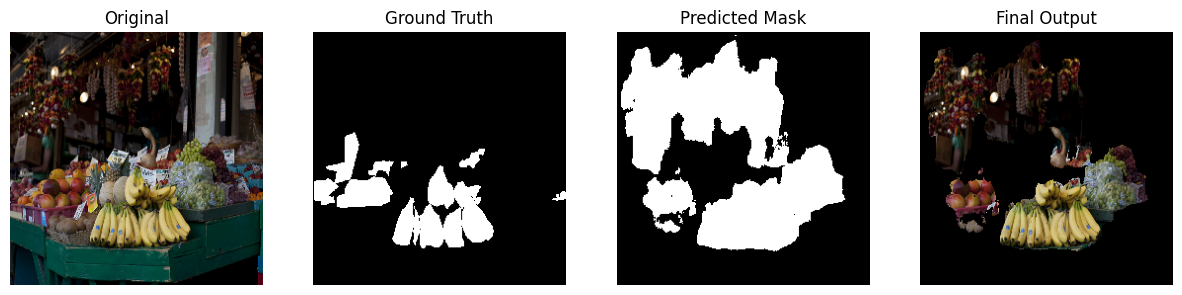

In [49]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(original_img)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Ground Truth")
plt.imshow(gt_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Final Output")
plt.imshow(final_output)
plt.axis("off")

plt.show()

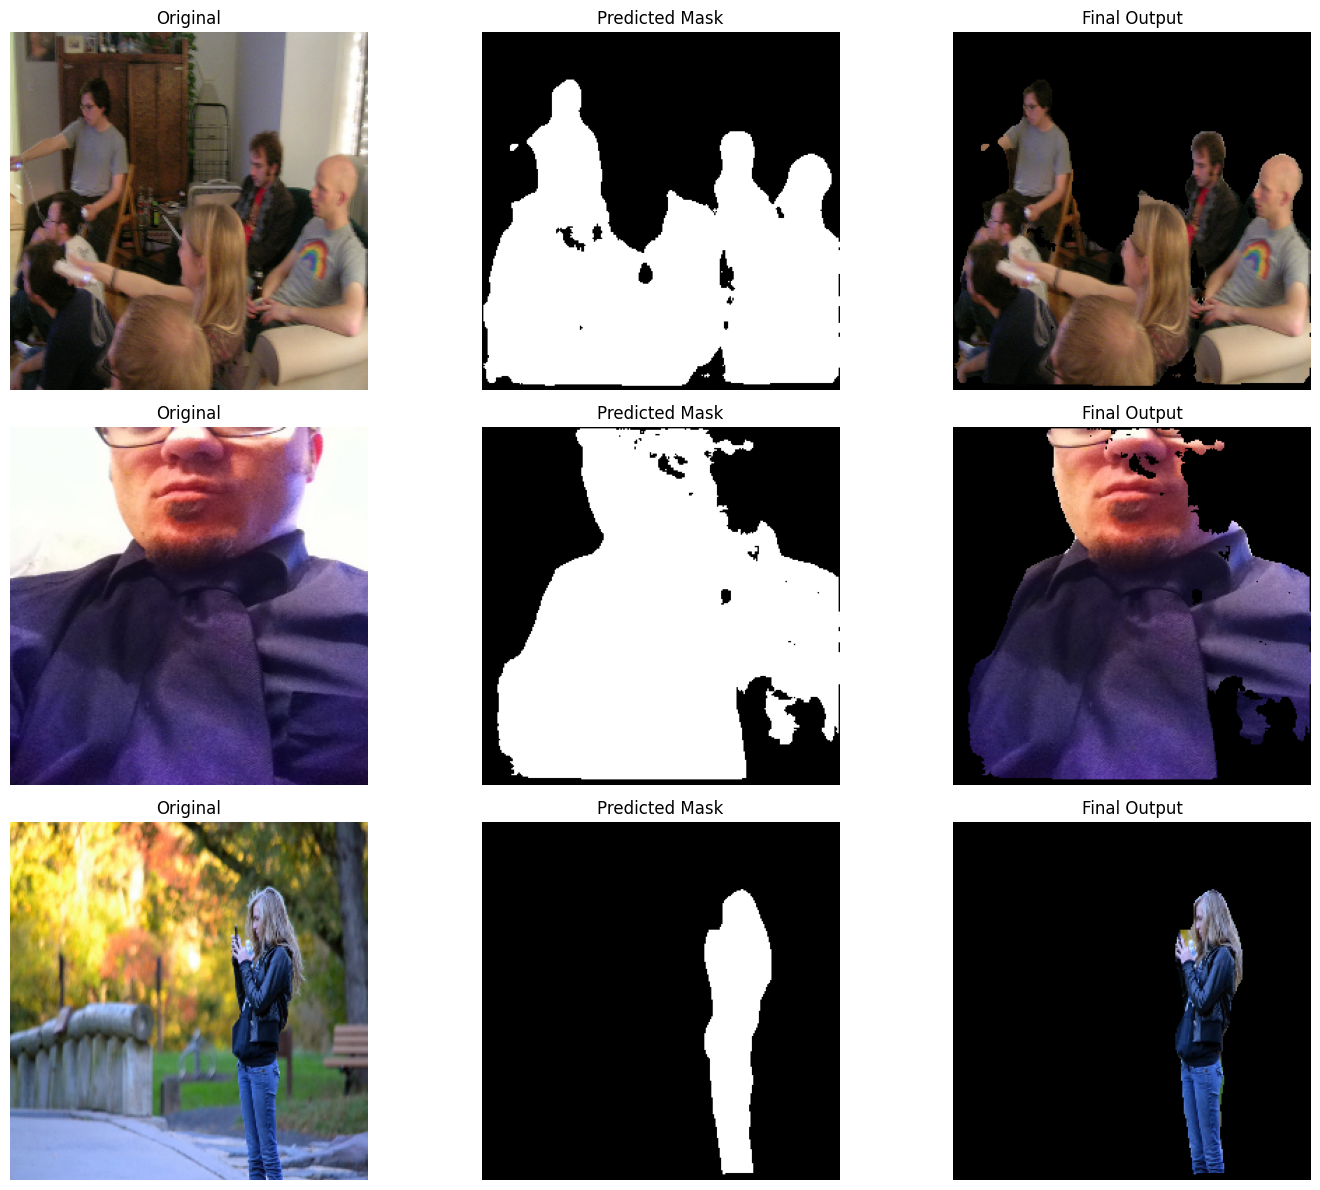

In [55]:
import matplotlib.pyplot as plt
import random

model.eval()

# Pick 3 random indices
indices = random.sample(range(len(val_dataset)), 3)

plt.figure(figsize=(15,12))

for row, idx in enumerate(indices):

    image, true_mask = val_dataset[idx]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image)

    pred = torch.sigmoid(pred)
    pred_binary = (pred > 0.5).float()

    output = image * pred_binary

    # Convert tensors to numpy
    original_img = image.squeeze(0).cpu().permute(1,2,0).numpy()
    pred_mask = pred_binary.squeeze(0).cpu().squeeze(0).numpy()
    final_output = output.squeeze(0).cpu().permute(1,2,0).numpy()

    # Plot original
    plt.subplot(3,3,row*3+1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    # Plot predicted mask
    plt.subplot(3,3,row*3+2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    # Plot final output
    plt.subplot(3,3,row*3+3)
    plt.imshow(final_output)
    plt.title("Final Output")
    plt.axis("off")

plt.tight_layout()
plt.show()